In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

In [64]:
ds1_126 = xr.open_dataset('pH_ensemble_ssp126_merged.nc').squeeze()
ds2_245 = xr.open_dataset('pH_ensemble_ssp245_merged.nc').squeeze()
ds3_585 = xr.open_dataset('pH_ensemble_ssp585_merged.nc').squeeze()

model_Ut_126=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/pH_std of ens models_ssp126.nc')
model_Ut_245=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/pH_std of ens models_ssp245.nc')
model_Ut_585=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/pH_std of ens models_ssp585.nc')

# ds1_126 = xr.open_dataset('pH_ensemble_ssp126_merged.nc').squeeze()
# ds2_245 = xr.open_dataset('pH_ensemble_ssp245_merged.nc').squeeze()
# ds3_585 = xr.open_dataset('pH_ensemble_ssp585_merged.nc').squeeze()

# model_Ut_126=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/H+_std of ens models_ssp126.nc')
# model_Ut_245=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/H+_std of ens models_ssp245.nc')
# model_Ut_585=xr.open_dataset('/media/athira/One Touch/final_datasets/Uncertainty/H+_std of ens models_ssp585.nc')


# ds1_126 = 10**(-1*ds1_126)
# ds2_245 = 10**(-1*ds2_245)
# ds3_585 = 10**(-1*ds3_585)

# model_Ut_126 =model_Ut_126*10**(9)
# model_Ut_245 =model_Ut_245*10**(9)
# model_Ut_585 =model_Ut_585*10**(9)



# ds1_126 = ds1_126*10**(9)
# ds2_245 = ds2_245*10**(9)
# ds3_585 = ds3_585*10**(9)



In [65]:
# model_Ut_126

In [51]:

plt.rcParams['font.weight'] = 'bold'

lat_range = slice(0, 30)  
lon_range = slice(30,120) 

# Subset and group data by year for each dataset
subset_ds1 = ds1_126.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2015')).groupby('time.year').mean()
subset_ds2 = ds1_126.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()
subset_ds3 = ds2_245.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()
subset_ds4 = ds3_585.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()
# subset_ds5 = ds4_585.sel(lat=lat_range, lon=lon_range, time=slice('2014', '2100')).groupby('time.year').mean()

model_Ut_hist_as = model_Ut_126.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2015')).groupby('time.year').mean()
model_Ut_126_as = model_Ut_126.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()
model_Ut_245_as = model_Ut_245.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()
model_Ut_585_as = model_Ut_585.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2100')).groupby('time.year').mean()


# Average over latitude and longitude
avg_subset_ds1 = subset_ds1.mean(['lat', 'lon'])
avg_subset_ds2 = subset_ds2.mean(['lat', 'lon'])
avg_subset_ds3 = subset_ds3.mean(['lat', 'lon'])
avg_subset_ds4 = subset_ds4.mean(['lat', 'lon'])
# avg_subset_ds5 = subset_ds5.mean(['lat', 'lon'])
avg_model_Ut_hist_as = model_Ut_hist_as.mean(['lat', 'lon'])
avg_model_Ut_126_as = model_Ut_126_as.mean(['lat', 'lon'])
avg_model_Ut_245_as = model_Ut_245_as.mean(['lat', 'lon'])
avg_model_Ut_585_as = model_Ut_585_as.mean(['lat', 'lon'])









In [52]:
avg_model_Ut_585_as

<xarray.Dataset> Size: 1kB
Dimensions:   (year: 86)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * year      (year) int64 688B 2015 2016 2017 2018 2019 ... 2097 2098 2099 2100
Data variables:
    ph        (year) float64 688B 0.1988 0.2295 0.2598 ... 0.5471 0.574 0.5182

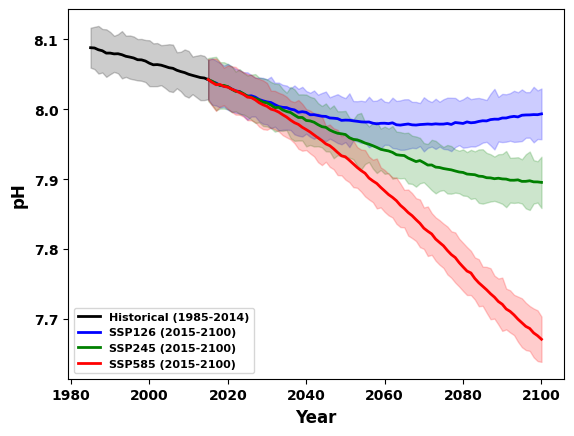

In [24]:

# Plot historical data from 1985 to 2014
plt.plot(avg_subset_ds1['year'], avg_subset_ds1['ph'], label='Historical (1985-2014)', linestyle='-', color='black', linewidth=2)

# Plot future projections from 2015 to 2100
plt.plot(avg_subset_ds2['year'], avg_subset_ds2['ph'], label='SSP126 (2015-2100)', linestyle='-', color='blue', linewidth=2)
plt.plot(avg_subset_ds3['year'], avg_subset_ds3['ph'], label='SSP245 (2015-2100)', linestyle='-', color='green', linewidth=2)
plt.plot(avg_subset_ds4['year'], avg_subset_ds4['ph'], label='SSP585 (2015-2100)', linestyle='-', color='red', linewidth=2)
# plt.plot(avg_subset_ds5['year'], avg_subset_ds5['ph'], label='SSP585 (2015-2100)', linestyle='-', color='violet', linewidth=2)
scenarios = [
    (avg_subset_ds1, avg_model_Ut_hist_as, 'black'),
    (avg_subset_ds2, avg_model_Ut_126_as, 'blue'),
    (avg_subset_ds3, avg_model_Ut_245_as, 'green'),
    (avg_subset_ds4, avg_model_Ut_585_as, 'red'),
]

for dataset, uncertainty, color in scenarios:
    # Ensure the uncertainty and pH data align in years
    year = dataset['year']
    ph_data = dataset['ph']
    uncertainty_values = uncertainty['ph']  # Extract uncertainty values

    plt.fill_between(
        year,
        ph_data - uncertainty_values * 3.1,  # Expand uncertainty range by a factor (e.g., 1.1)
        ph_data + uncertainty_values * 3.1,
        color=color,
        alpha=0.2  # Adjust alpha for better visibility
    )

# Customize plot
# plt.title('Bias-corrected multi-model Ensemble pH from 1985 to 2100', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('pH', fontsize=12, fontweight='bold')
plt.legend(fontsize=8, loc='lower left')
# plt.savefig(
#     "timeseries_pH_ens.png",
#     dpi=300,
#     bbox_inches="tight"
# )
# plt.grid(False, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


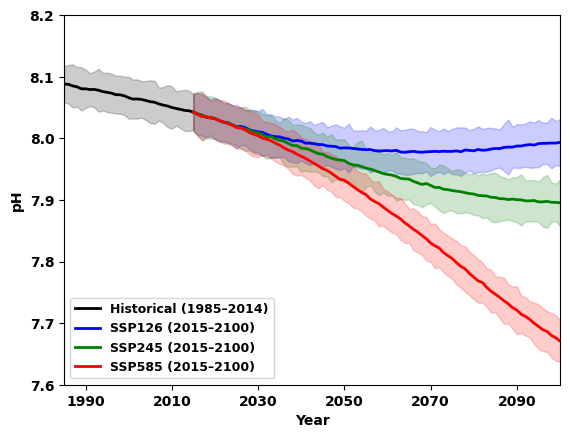

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plot historical data
# -----------------------------
plt.plot(
    avg_subset_ds1['year'], avg_subset_ds1['ph'],
    label='Historical (1985–2014)',
    linestyle='-', color='black', linewidth=2
)

# -----------------------------
# Plot future projections
# -----------------------------
plt.plot(avg_subset_ds2['year'], avg_subset_ds2['ph'],
         label='SSP126 (2015–2100)', color='blue', linewidth=2)
plt.plot(avg_subset_ds3['year'], avg_subset_ds3['ph'],
         label='SSP245 (2015–2100)', color='green', linewidth=2)
plt.plot(avg_subset_ds4['year'], avg_subset_ds4['ph'],
         label='SSP585 (2015–2100)', color='red', linewidth=2)

# -----------------------------
# Uncertainty shading
# -----------------------------
scenarios = [
    (avg_subset_ds1, avg_model_Ut_hist_as, 'black'),
    (avg_subset_ds2, avg_model_Ut_126_as, 'blue'),
    (avg_subset_ds3, avg_model_Ut_245_as, 'green'),
    (avg_subset_ds4, avg_model_Ut_585_as, 'red'),
]

for dataset, uncertainty, color in scenarios:
    year = dataset['year']
    ph_data = dataset['ph']
    uncertainty_values = uncertainty['ph']

    plt.fill_between(
        year,
        ph_data - uncertainty_values * 3.2,
        ph_data + uncertainty_values * 3.2,
        color=color,
        alpha=0.2
    )

# -----------------------------
# Axis customization (KEY CHANGES)
# -----------------------------

# Y-axis range and ticks
plt.ylim(7.6, 8.2)
plt.yticks(np.arange(7.6, 8.21, 0.1))

# X-axis: remove extra tick at the end
years_all = np.concatenate([
    avg_subset_ds1['year'].values,
    avg_subset_ds2['year'].values
])

plt.xlim(years_all.min(), years_all.max())
plt.xticks(np.arange(1990, 2101, 20))  # decade ticks only

# -----------------------------
# Labels, legend, save
# -----------------------------
plt.xlabel('Year', fontsize=10, fontweight='bold')
plt.ylabel('pH', fontsize=10, fontweight='bold')
plt.legend(fontsize=9, loc='lower left')

plt.savefig(
    "timeseries_pH_ens_v2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# H+

In [66]:
# import numpy as np
# import matplotlib.pyplot as plt

# # -----------------------------
# # Plot historical data
# # -----------------------------
# plt.plot(
#     avg_subset_ds1['year'], avg_subset_ds1['ph'],
#     label='Historical (1985–2014)',
#     linestyle='-', color='black', linewidth=2
# )

# # -----------------------------
# # Plot future projections
# # -----------------------------
# plt.plot(avg_subset_ds2['year'], avg_subset_ds2['ph'],
#          label='SSP126 (2015–2100)', color='blue', linewidth=2)
# plt.plot(avg_subset_ds3['year'], avg_subset_ds3['ph'],
#          label='SSP245 (2015–2100)', color='green', linewidth=2)
# plt.plot(avg_subset_ds4['year'], avg_subset_ds4['ph'],
#          label='SSP585 (2015–2100)', color='red', linewidth=2)

# # -----------------------------
# # Uncertainty shading
# # -----------------------------
# scenarios = [
#     (avg_subset_ds1, avg_model_Ut_hist_as, 'black'),
#     (avg_subset_ds2, avg_model_Ut_126_as, 'blue'),
#     (avg_subset_ds3, avg_model_Ut_245_as, 'green'),
#     (avg_subset_ds4, avg_model_Ut_585_as, 'red'),
# ]

# for dataset, uncertainty, color in scenarios:
#     year = dataset['year']
#     ph_data = dataset['ph']
#     uncertainty_values = uncertainty['ph']

#     plt.fill_between(
#         year,
#         ph_data - uncertainty_values * 3.2,
#         ph_data + uncertainty_values * 3.2,
#         color=color,
#         alpha=0.2
#     )

# # -----------------------------
# # Axis customization (KEY CHANGES)
# # -----------------------------

# # Y-axis range and ticks
# plt.ylim(7, 24)
# plt.yticks(np.arange(7, 24, 3))

# # X-axis: remove extra tick at the end
# years_all = np.concatenate([
#     avg_subset_ds1['year'].values,
#     avg_subset_ds2['year'].values
# ])

# plt.xlim(years_all.min(), years_all.max())
# plt.xticks(np.arange(1990, 2101, 20))  # decade ticks only

# # -----------------------------
# # Labels, legend, save
# # -----------------------------
# plt.xlabel('Year', fontsize=10, fontweight='bold')
# plt.ylabel('[H+]', fontsize=10, fontweight='bold')
# plt.legend(fontsize=9, loc='upper left')

# plt.savefig(
#     "timeseries_[H+]_ens_v2.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()
